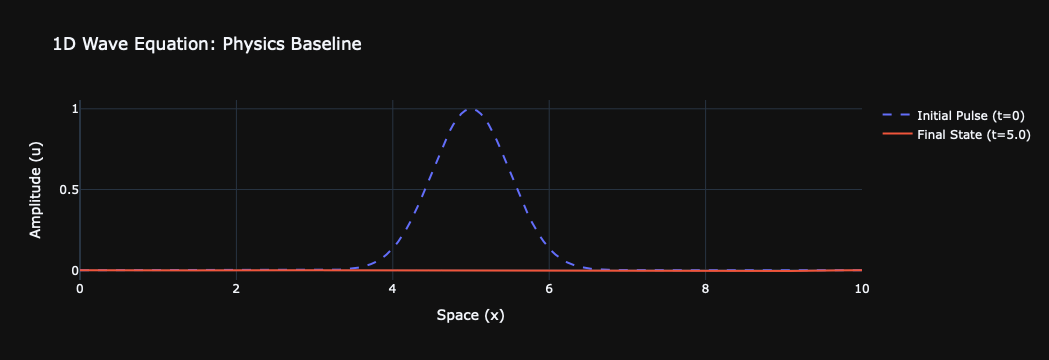

In [1]:
import numpy as np
import plotly.graph_objects as go

# 1. Define the Grid (Space and Time)
L = 10.0          # Length of the domain (e.g., the optical fiber)
T = 5.0           # Total time to simulate
nx = 200          # Number of spatial points
nt = 400          # Number of time steps
c = 1.0           # Wave speed

dx = L / (nx - 1)
dt = T / (nt - 1)

# Courant number (must be <= 1 for stability in finite difference)
C = c * dt / dx   

# 2. Initialize the arrays
x = np.linspace(0, L, nx)
u = np.zeros(nx)       # Current time step
u_prev = np.zeros(nx)  # Previous time step
u_next = np.zeros(nx)  # Next time step

# 3. Set the Initial Condition (A Gaussian pulse representing our laser)
u_prev = np.exp(-0.5 * ((x - L/2) / 0.5)**2)
u = np.copy(u_prev)

# We will store the history to visualize it later
history = [np.copy(u)]

# 4. Finite Difference Time Stepping
for n in range(1, nt):
    for i in range(1, nx - 1):
        u_next[i] = 2 * u[i] - u_prev[i] + (C**2) * (u[i+1] - 2*u[i] + u[i-1])
    
    # Boundary conditions (keeping the ends fixed at 0)
    u_next[0] = 0
    u_next[-1] = 0
    
    # Move forward in time
    u_prev = np.copy(u)
    u = np.copy(u_next)
    history.append(np.copy(u))

# 5. Visualize the initial and final state with Plotly
fig = go.Figure()
fig.add_trace(go.Scatter(x=x, y=history[0], mode='lines', name='Initial Pulse (t=0)', line=dict(dash='dash')))
fig.add_trace(go.Scatter(x=x, y=history[-1], mode='lines', name=f'Final State (t={T})'))

fig.update_layout(title='1D Wave Equation: Physics Baseline',
                  xaxis_title='Space (x)',
                  yaxis_title='Amplitude (u)',
                  template='plotly_dark') # A dark theme looks better for physics dashboards!
fig.show()

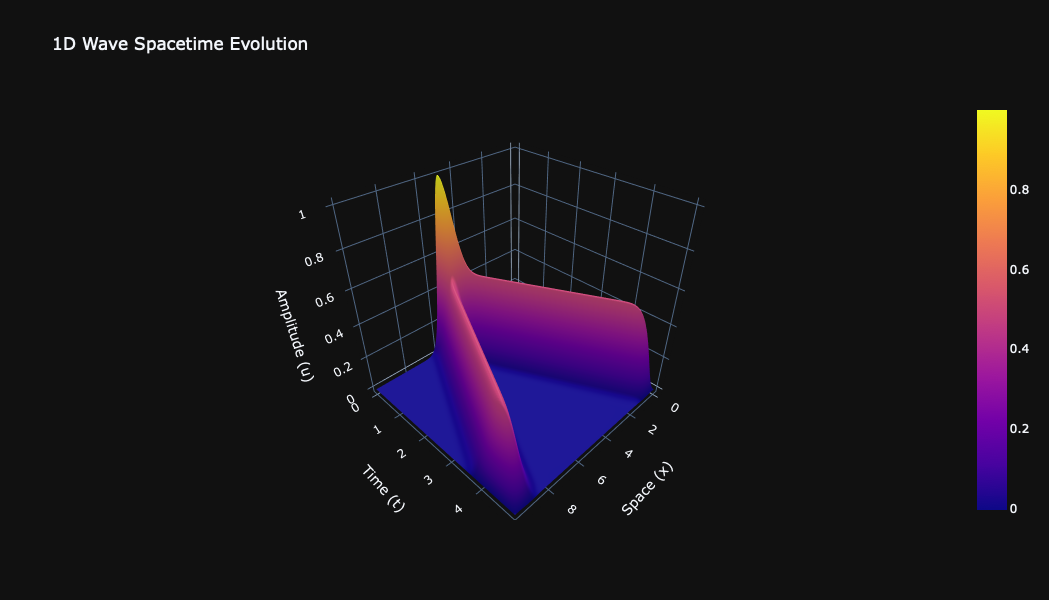

In [2]:
# Convert our history list into a 2D NumPy array
# Shape will be (nt, nx) -> (Time, Space)
Z = np.array(history)

# Create a 3D Surface Plot
fig_3d = go.Figure(data=[go.Surface(z=Z, x=x, y=np.linspace(0, T, nt), colorscale='Plasma')])

fig_3d.update_layout(title='1D Wave Spacetime Evolution',
                     scene=dict(
                         xaxis_title='Space (x)',
                         yaxis_title='Time (t)',
                         zaxis_title='Amplitude (u)'
                     ),
                     template='plotly_dark',
                     autosize=False,
                     width=800,
                     height=600)

fig_3d.show()